In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import genpareto,norm

In [13]:
#1. Tail Behaviour Analysis

data_crypto=pd.read_csv("C:\\Users\\Divisha Nain\\Downloads\\residualscrypto.csv")
data_tech=pd.read_csv("C:\\Users\\Divisha Nain\\Downloads\\residualstech.csv")
residual_crypto=data_crypto["crypto_resid"]
losses_crypto=data_crypto["crytpo_losses"]
residual_tech=data_tech["Tech_resid"]
losses_tech=data_tech["tech_losses"]


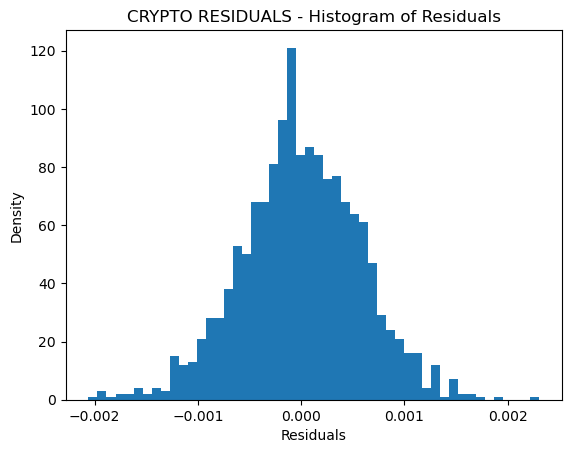

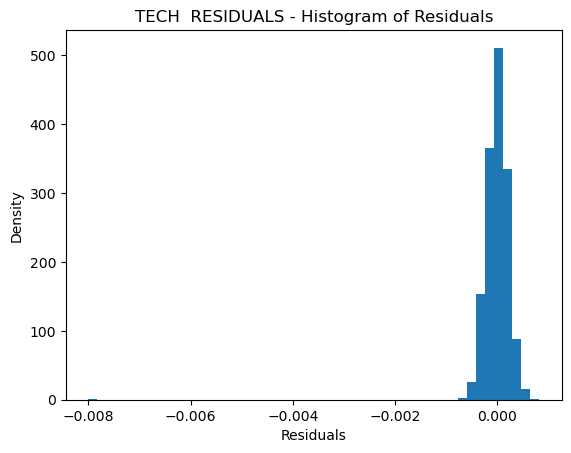

In [18]:
#1. Histogram of Residuals
def plot_histogram(residuals, title):
    plt.figure()
    plt.hist(residuals, bins=50)
    plt.title(f"{title} - Histogram of Residuals")
    plt.xlabel("Residuals")
    plt.ylabel("Density")
    plt.show()
 
plot_histogram(residual_crypto, "CRYPTO RESIDUALS")    
plot_histogram(residual_tech,"TECH  RESIDUALS")


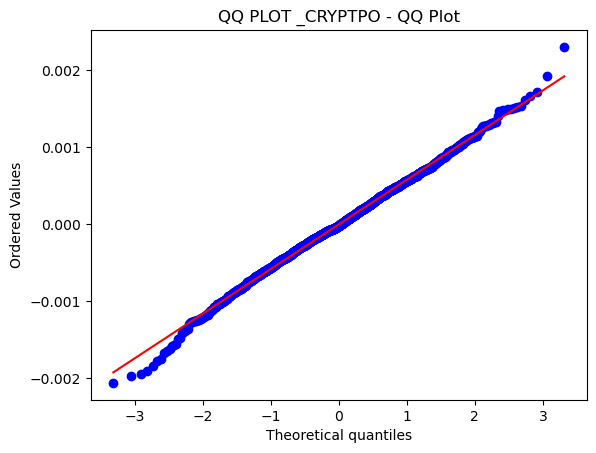

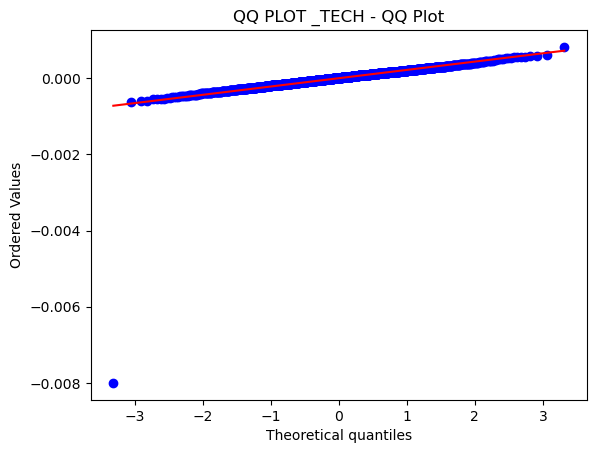

In [15]:
#QQ Plot (Check Fat Tails)
def plot_qq(residuals, title):
    plt.figure()
    stats.probplot(residuals, dist="norm", plot=plt)
    plt.title(f"{title} - QQ Plot")
    plt.show()
    
plot_qq(residual_crypto, "QQ PLOT _CRYPTPO")
plot_qq(residual_tech, "QQ PLOT _TECH")



In [16]:
def EVT_VaR_ES(residuals, confidence_level=0.99):
    

    
    # Threshold (95%)
    threshold = np.percentile(residuals, 95)
    
    # Exceedances
    exceedances = residuals[residuals > threshold] - threshold
    
    # Fit GPD
    shape, loc, scale = genpareto.fit(exceedances)
    
    n = len(residuals)
    nu = len(exceedances)
    
    # EVT VaR
    VaR_evt = threshold + (scale/shape) * (((n/nu)*(1-confidence_level))**(-shape) - 1)
    
    # EVT ES
    ES_evt = (VaR_evt + (scale - shape * threshold)) / (1 - shape)
    
    # Gaussian VaR
    mu = np.mean(residuals)
    sigma = np.std(residuals)
    VaR_gaussian = norm.ppf(confidence_level, mu, sigma)
    
    return {
        "Threshold": threshold,
        "Shape_xi": shape,
        "Scale_beta": scale,
        "VaR_EVT": VaR_evt,
        "ES_EVT": ES_evt,
        "VaR_Gaussian": VaR_gaussian
    }

results_crypto = EVT_VaR_ES(residual_crypto)
results_tech = EVT_VaR_ES(residual_tech)

print("CRYPTO Results")
for k, v in results_crypto.items():
    print(f"{k}: {v}")

print("\nTECH Results")
for k, v in results_tech.items():
    print(f"{k}: {v}")


CRYPTO Results
Threshold: 0.0009460808317068999
Shape_xi: 0.4807372118747416
Scale_beta: 0.0001980735775089055
VaR_EVT: 0.0014275282017147655
ES_EVT: 0.002254707143964143
VaR_Gaussian: 0.0013496422578601545

TECH Results
Threshold: 0.0003293480031901599
Shape_xi: 0.47977543786623933
Scale_beta: 6.995187044491817e-05
VaR_EVT: 0.0004992280721649587
ES_EVT: 0.0007903641813498738
VaR_Gaussian: 0.0006718226295211237


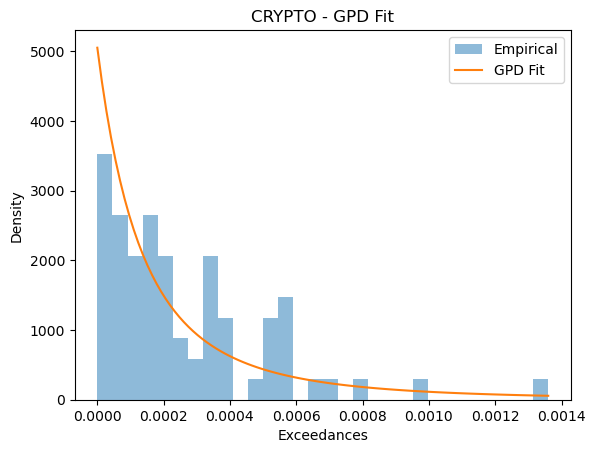

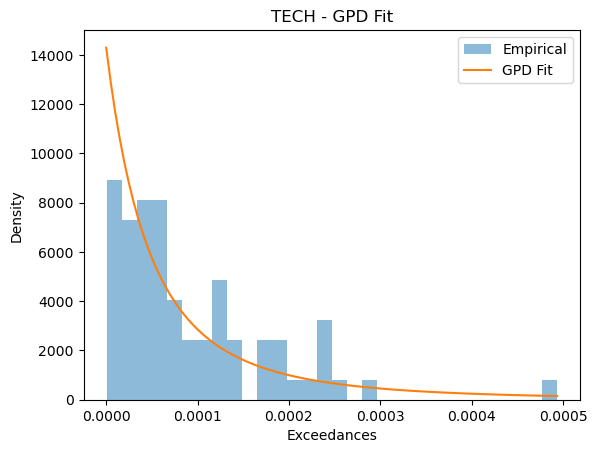

In [17]:
#GPD Fit vs Data (Tail Fit)
def plot_gpd_fit(residuals, threshold, shape, scale, title):
    
    exceedances = residuals[residuals > threshold] - threshold
    
    plt.figure()
    plt.hist(exceedances, bins=30, density=True, alpha=0.5, label="Empirical")

    x = np.linspace(0, max(exceedances), 100)
    y = genpareto.pdf(x, shape, loc=0, scale=scale)

    plt.plot(x, y, label="GPD Fit")
    plt.title(f"{title} - GPD Fit")
    plt.xlabel("Exceedances")
    plt.ylabel("Density")
    plt.legend()
    plt.show()
    

plot_gpd_fit(residual_crypto, results_crypto["Threshold"], 
             results_crypto["Shape_xi"], 
             results_crypto["Scale_beta"], 
             "CRYPTO")


plot_gpd_fit(residual_tech, results_tech["Threshold"], 
             results_tech["Shape_xi"], 
             results_tech["Scale_beta"], 
             "TECH")  